## **Aprendizaje de Máquina**

dataset_elpino.csv utilizando K-Prototypes (No Supervisado)

### *Primera parte: Limpieza del dataset*

In [30]:
# Importaciones
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [31]:
# Cargar el dataset
data = pd.read_csv("data/dataset_elpino.csv", sep=";")

In [32]:
def limpiar_grd(data_raw):
    data = data_raw.copy()
    
    # Limpieza de Sexo y Edad
    # Convertimos a binario: Mujer=0, Hombre=1
    data["Sexo_Binario"] = data["Sexo (Desc)"].map({"Mujer": 0, "Hombre": 1})
    
    # Crear variable "Cantidad de procedimientos secundarios"
    # Contamos cuántas columnas de Proced 02 a Proced 30 NO son '-' y NO son nulas
    proced_cols = data.loc[:, "Proced 02 Secundario (cod+des)":"Proced 30 Secundario (cod+des)"]
    data["Cant_Proced_Secundarios"] = proced_cols.apply(
        lambda row: row.notna().sum() - (row == "-").sum(), axis=1
    )
    
    # Crear variable "Cantidad de diagnósticos secundarios"
    # Contamos cuántas columnas de Diag 02 a Diag 35 NO son '-' y NO son nulas
    diag_secundarios = data.loc[:, "Diag 02 Secundario (cod+des)":"Diag 35 Secundario (cod+des)"]
    data["Cant_Diag_Secundarios"] = diag_secundarios.apply(
        lambda row: row.notna().sum() - (row == "-").sum(), axis=1
    )
    
    # Extraer Familia del Diagnóstico Principal (Primeros 3 caracteres)
    # Ej: "A41.8 - Otras..." -> "A41"
    # Esto reduce miles de enfermedades a unas pocas cientos de familias
    data["Diag_Principal_Familia"] = data["Diag 01 Principal (cod+des)"].str[:3]
      
    # Manejo de Outliers / Errores (Códigos 990.000)
    # Creamos una bandera para identificarlos, pero no los borramos aún, 
    # servirán para ver si el modelo los agrupa solos.
    data["Es_Error_GRD"] = data["GRD"].str.contains("9900", na=False).astype(int)
    
    # Seleccionar solo lo que sirve para el modelo NO SUPERVISADO
    # No le pases las 68 columnas de texto al modelo, pásale las procesadas.
    
    columnas_modelo = [
        "Edad en años",
        "Sexo_Binario",
        "Cant_Proced_Secundarios",
        "Cant_Diag_Secundarios",
        "Diag_Principal_Familia"
    ]
    
    # Devolvemos el limpio para el modelo y el original con extras
    return data[columnas_modelo], data

data_para_modelos, data_final = limpiar_grd(data)

print("Dataset listo para clustering: \n")
print(data_para_modelos.head())

Dataset listo para clustering: 

   Edad en años  Sexo_Binario  Cant_Proced_Secundarios  Cant_Diag_Secundarios  \
0            40             1                       29                     27   
1            53             1                       29                     16   
2            65             1                       29                     31   
3            61             1                       29                     18   
4            30             1                       29                     21   

  Diag_Principal_Familia  
0                    A41  
1                    U07  
2                    K56  
3                    K76  
4                    T81  


¿Por qué lo limpiamos así?

Reducción de Ruido: Al pasar de 68 columnas a 5 variables clave, el modelo de clustering (K-Means o K-Prototypes) encontrará grupos mucho más rápido y con mayor sentido clínico.

Cant_Diag_Secundarios: Esta es tu variable de "Severidad". Un paciente con 15 diagnósticos secundarios se agrupará naturalmente lejos de uno que tiene 0, lo cual es correcto en GRD.

Diag_Principal_Familia: Al tomar solo los primeros 3 caracteres (la letra y dos números del CIE-10), agrupas por tipo de enfermedad. Esto evita que el modelo trate como "cosas totalmente distintas" a dos tipos de neumonías ligeramente diferentes.

In [33]:
data_para_modelos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14561 entries, 0 to 14560
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Edad en años             14561 non-null  int64 
 1   Sexo_Binario             14561 non-null  int64 
 2   Cant_Proced_Secundarios  14561 non-null  int64 
 3   Cant_Diag_Secundarios    14561 non-null  int64 
 4   Diag_Principal_Familia   14561 non-null  object
dtypes: int64(4), object(1)
memory usage: 568.9+ KB


### *Segunda Parte: Clustering*

In [34]:
# Importaciones para el Clustering
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from kmodes.kprototypes import KPrototypes
from sklearn.decomposition import PCA

In [35]:
from kmodes.kprototypes import KPrototypes

# 1. Preparamos los datos
# K-Prototypes necesita saber qué columnas son texto (categorías)
# En tu caso, 'Diag_Principal_Familia' es la columna índice 4
indice_cat = [4] 

# 2. Convertimos a matriz para el modelo
X_matriz = data_para_modelos.values

# 3. Entrenamos el modelo (Ejemplo con 4 grupos)
# Con tu i5-12600K, esto tardará muy poco
kproto = KPrototypes(n_clusters=4, init='Cao', verbose=1)
clusters = kproto.fit_predict(X_matriz, categorical=indice_cat)

# 4. Guardamos el resultado
data_final['Cluster'] = clusters

Initialization method and algorithm are deterministic. Setting n_init to 1.
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 1, iteration: 1/100, moves: 4821, ncost: 2078173.4323042668
Run: 1, iteration: 2/100, moves: 2067, ncost: 1890393.659285187
Run: 1, iteration: 3/100, moves: 2129, ncost: 1671853.9790358383
Run: 1, iteration: 4/100, moves: 1118, ncost: 1626600.1886515368
Run: 1, iteration: 5/100, moves: 295, ncost: 1622379.488176325
Run: 1, iteration: 6/100, moves: 94, ncost: 1621670.1989842288
Run: 1, iteration: 7/100, moves: 48, ncost: 1621461.6514082842
Run: 1, iteration: 8/100, moves: 42, ncost: 1621376.8652352334
Run: 1, iteration: 9/100, moves: 24, ncost: 1621335.0139570688
Run: 1, iteration: 10/100, moves: 31, ncost: 1621250.9823084401
Run: 1, iteration: 11/100, moves: 52, ncost: 1621081.599832573
Run: 1, iteration: 12/100, moves: 39, ncost: 1620984.131948314
Run: 1, iteration: 13/100, moves: 16, ncost: 1620956.9033838303
Run: 1, iteratio

In [40]:
# 1. Asignar los resultados al dataset original
data_final['Cluster'] = clusters

# 2. Ver el "Perfil" de cada grupo (Promedios)
# Esto nos dirá quiénes están en cada grupo
perfiles = data_final.groupby('Cluster').agg({
    'Edad en años': 'mean',
    'Cant_Diag_Secundarios': 'mean',
    'Cant_Proced_Secundarios': 'mean',
    'Sexo_Binario': 'mean',
    'Diag_Principal_Familia': lambda x: x.value_counts().index[0] # La enfermedad más común del grupo
}).reset_index()

print("Resumen de los Grupos Encontrados: \n")
print(perfiles)

Resumen de los Grupos Encontrados: 

   Cluster  Edad en años  Cant_Diag_Secundarios  Cant_Proced_Secundarios  \
0        0     74.667454              10.396965                18.826644   
1        1     53.777672               5.447185                12.189121   
2        2      2.297068               2.317467                 7.753506   
3        3     29.148331               5.985035                10.737050   

   Sexo_Binario Diag_Principal_Familia  
0      0.488702                    U07  
1      0.463631                    K80  
2      0.499363                    P59  
3      0.140437                    O70  


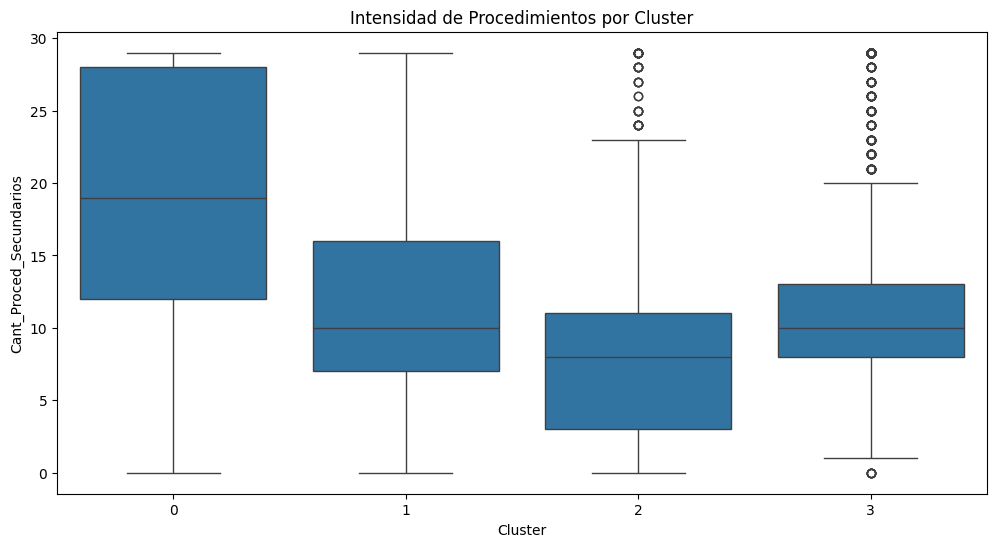

In [37]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Cluster', y='Cant_Proced_Secundarios', data=data_final)
plt.title('Intensidad de Procedimientos por Cluster')
plt.show()

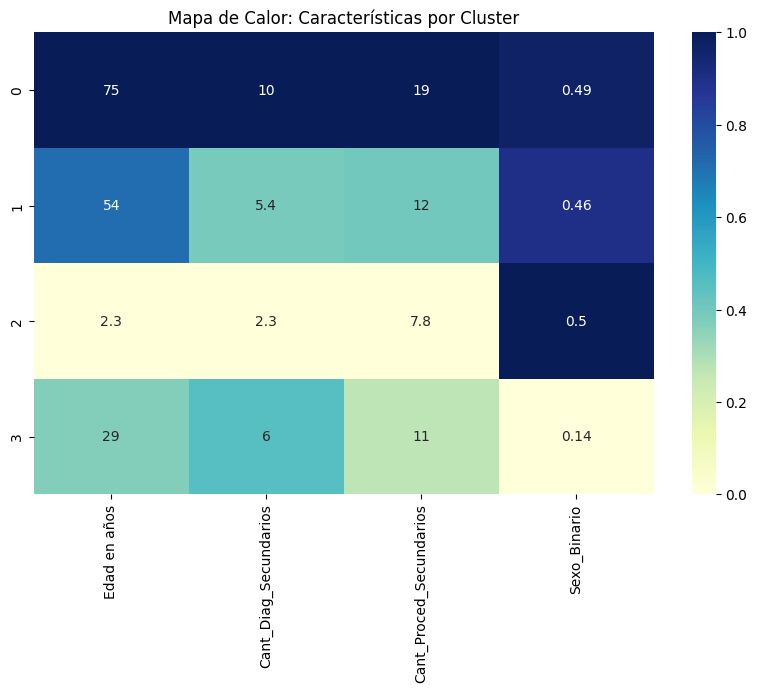

In [38]:
# Normalizamos los perfiles para que se vean bien en el mapa de calor
perfiles_norm = (perfiles.iloc[:, 1:-1] - perfiles.iloc[:, 1:-1].min()) / (perfiles.iloc[:, 1:-1].max() - perfiles.iloc[:, 1:-1].min())

plt.figure(figsize=(10, 6))
sns.heatmap(perfiles_norm, annot=perfiles.iloc[:, 1:-1], cmap="YlGnBu")
plt.title("Mapa de Calor: Características por Cluster")
plt.show()

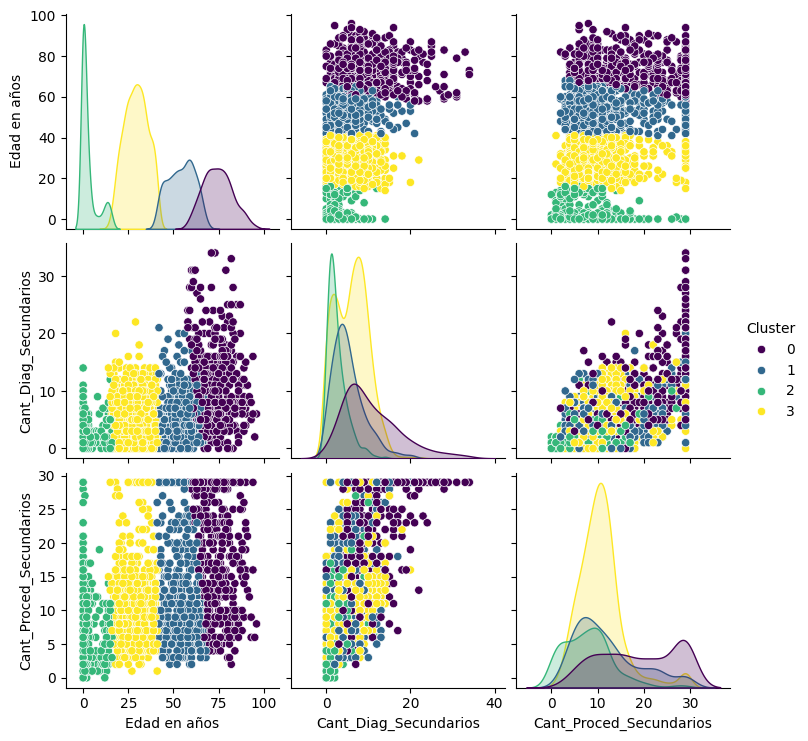

In [39]:
sns.pairplot(data_final.sample(2000), vars=['Edad en años', 'Cant_Diag_Secundarios', 'Cant_Proced_Secundarios'], 
             hue='Cluster', palette='viridis', diag_kind='kde')
plt.show()

In [ ]:
# Ver cuántas familias de enfermedades distintas hay en el Cluster 0
print(f"Familias distintas en Cluster 0: {data_final[data_final['Cluster'] == 0]['Diag_Principal_Familia'].nunique()}")

# Ver las 5 familias más comunes de ese cluster
print(data_final[data_final['Cluster'] == 1]['Diag_Principal_Familia'].value_counts().head(5))

Familias distintas en Cluster 0: 303
Diag_Principal_Familia
U07    230
I50    223
I63    144
E11    125
J44    110
Name: count, dtype: int64
